<a href="https://colab.research.google.com/github/jayashreesettu/Banknote-Authentication/blob/main/ML_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Preparation for SVC

First, we need to separate our features (X) from our target variable (y). Then, we will split the data into training and testing sets. Finally, we'll scale the features using `StandardScaler`, which is important for SVMs.

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/diabetes.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

# Display basic information about the DataFrame
df.info()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Correlation Matrix

Let's examine the correlation between the features in our dataset using a heatmap. This helps in understanding potential multicollinearity and the relationship of features with the target variable.

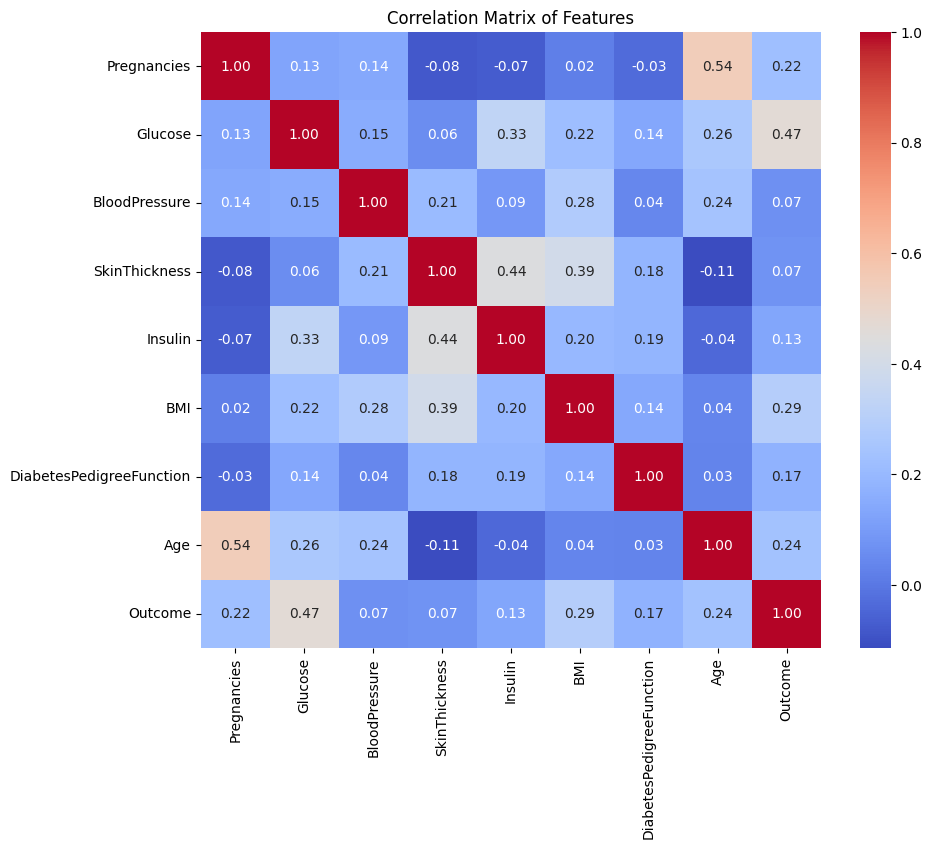

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
corr_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

### Features Most Correlated with 'Outcome'

Let's identify the features that have the strongest positive or negative correlation with our target variable, 'Outcome'.

In [ ]:
# Get correlations with 'Outcome'
outcome_correlations = corr_matrix['Outcome'].sort_values(ascending=False)

# Exclude 'Outcome' itself from the list
outcome_correlations = outcome_correlations.drop('Outcome')

print("Features with highest correlation to 'Outcome':\n")
display(outcome_correlations)

Features with highest correlation to 'Outcome':



,Outcome
Glucose,0.466581
BMI,0.292695
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
Insulin,0.130548
SkinThickness,0.074752
BloodPressure,0.065068


### Scatter Plot: Glucose vs. Outcome

Let's visualize the distribution of 'Glucose' values across the two 'Outcome' classes (0 and 1) to understand their relationship.

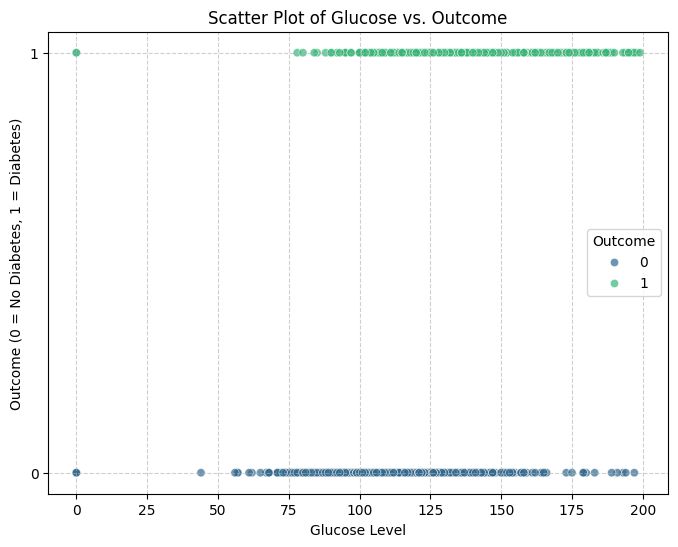

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Glucose', y='Outcome', data=df, hue='Outcome', palette='viridis', alpha=0.7)
plt.title('Scatter Plot of Glucose vs. Outcome')
plt.xlabel('Glucose Level')
plt.ylabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.yticks([0, 1]) # Ensure y-axis shows only 0 and 1
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Distribution of Glucose

Let's visualize the distribution of the 'Glucose' feature to see if it approximates a normal distribution.

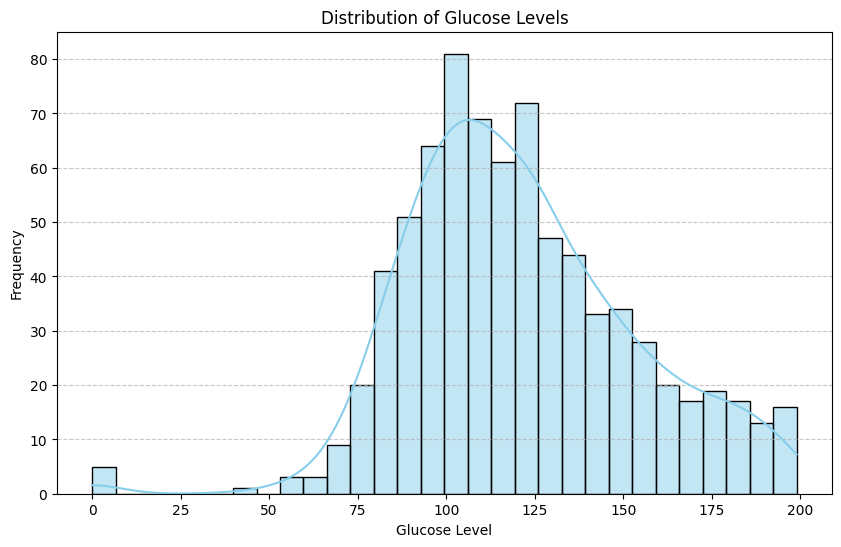

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Glucose'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Glucose Levels')
plt.xlabel('Glucose Level')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preparation complete: Features scaled and split into training and testing sets.")

Data preparation complete: Features scaled and split into training and testing sets.


### Support Vector Classification with GridSearchCV

Now, let's implement a Support Vector Classifier and use `GridSearchCV` to find the best hyperparameters. `GridSearchCV` exhaustively searches over specified parameter values for an estimator.

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define the SVC model
svc = SVC(random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the scaled training data
grid_search.fit(X_train_scaled, y_train)

# Print the best parameters and best score found by GridSearchCV
print(f"Best parameters from GridSearchCV: {grid_search.best_params_}")
print(f"Best accuracy score from GridSearchCV: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters from GridSearchCV: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best accuracy score from GridSearchCV: 0.7720


### Support Vector Classification with RandomizedSearchCV

Next, we'll use `RandomizedSearchCV` for hyperparameter tuning. This method samples a fixed number of parameter settings from specified distributions, which can be more efficient for large parameter spaces.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform

# Define the parameter distributions for RandomizedSearchCV
param_distributions = {
    'C': loguniform(0.1, 100),
    'gamma': loguniform(0.001, 1),
    'kernel': ['rbf', 'linear']
}

# Initialize RandomizedSearchCV
# n_iter specifies the number of parameter settings that are sampled
random_search = RandomizedSearchCV(svc, param_distributions, n_iter=50, cv=5, scoring='accuracy', n_jobs=-1, verbose=1, random_state=42)

# Fit RandomizedSearchCV to the scaled training data
random_search.fit(X_train_scaled, y_train)

# Print the best parameters and best score found by RandomizedSearchCV
print(f"Best parameters from RandomizedSearchCV: {random_search.best_params_}")
print(f"Best accuracy score from RandomizedSearchCV: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters from RandomizedSearchCV: {'C': np.float64(4.895834359555105), 'gamma': np.float64(0.12205294397769412), 'kernel': 'rbf'}
Best accuracy score from RandomizedSearchCV: 0.7688


### Model Evaluation

Let's evaluate the performance of the best models obtained from both GridSearchCV and RandomizedSearchCV on the test set.

GridSearchCV Best Model Evaluation:
Accuracy: 0.7727
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.82        99
           1       0.69      0.67      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



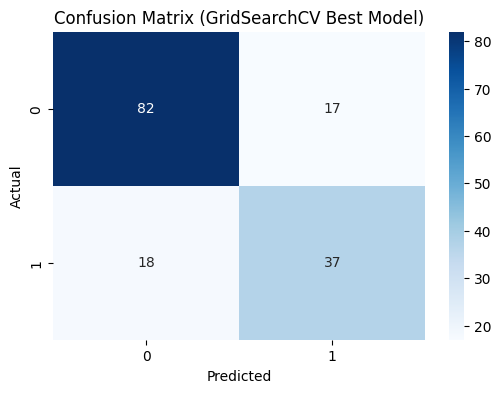


RandomizedSearchCV Best Model Evaluation:
Accuracy: 0.7273
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.81      0.79        99
           1       0.63      0.58      0.60        55

    accuracy                           0.73       154
   macro avg       0.70      0.69      0.70       154
weighted avg       0.72      0.73      0.72       154



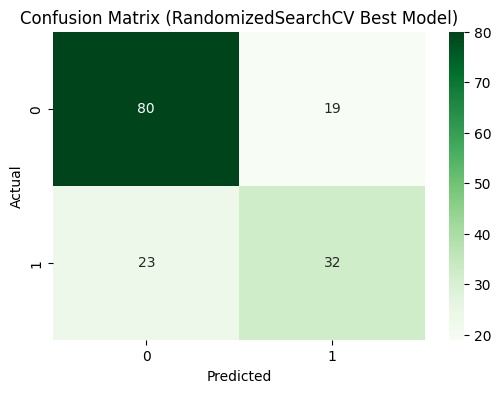

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate the best model from GridSearchCV
best_grid_model = grid_search.best_estimator_
y_pred_grid = best_grid_model.predict(X_test_scaled)

print("GridSearchCV Best Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_grid):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_grid))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_grid), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (GridSearchCV Best Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Evaluate the best model from RandomizedSearchCV
best_random_model = random_search.best_estimator_
y_pred_random = best_random_model.predict(X_test_scaled)

print("\nRandomizedSearchCV Best Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_random):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_random))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_random), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix (RandomizedSearchCV Best Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Cross-Validation Scores

Let's further assess the generalization performance of our best models by calculating their cross-validation scores on the training data.

In [ ]:
from sklearn.model_selection import cross_val_score

# Cross-validation for the best GridSearchCV model
cv_scores_grid = cross_val_score(best_grid_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation scores for GridSearchCV best model: {cv_scores_grid}")
print(f"Mean CV accuracy for GridSearchCV best model: {cv_scores_grid.mean():.4f}")

# Cross-validation for the best RandomizedSearchCV model
cv_scores_random = cross_val_score(best_random_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"\nCross-validation scores for RandomizedSearchCV best model: {cv_scores_random}")
print(f"Mean CV accuracy for RandomizedSearchCV best model: {cv_scores_random.mean():.4f}")

Cross-validation scores for GridSearchCV best model: [0.76422764 0.81300813 0.76422764 0.73170732 0.78688525]
Mean CV accuracy for GridSearchCV best model: 0.7720

Cross-validation scores for RandomizedSearchCV best model: [0.77235772 0.81300813 0.71544715 0.75609756 0.78688525]
Mean CV accuracy for RandomizedSearchCV best model: 0.7688
